# N-gram Language Model: 16 langkah
Fase 1, Brown penuh, Python/Counter. Semua angka berasal dari kernel ini.

## Asumsi & Keputusan Desain
- Brown sudah bertokenisasi; `tokenize()` tersedia untuk input teks baru. Filter `str.isalpha()` mempertahankan huruf Unicode.
- Split acak **indeks kalimat** 80/20, seed 42. Statistik eksplorasi seluruh corpus hanya deskriptif; vocabulary/count model memakai train saja.
- Kalimat identik dapat berada di kedua partisi; indeks sumber tetap terpisah. Evaluasi bukan generalisasi lintas dokumen.
- `min_count=2`; target vocabulary termasuk `<UNK>` dan `</s>`, mengecualikan `<s>`.
- Padding n−1 `<s>`; satu `</s>`. Unigram tidak memprediksi `<s>`. Penyebut konteks dihitung dari event prediksi, tanpa EOS sebagai konteks terminal.
- Log natural, `log(0)=-inf`; N mencakup EOS, mengecualikan BOS.


In [1]:
import hashlib
import json
import math
import os
import platform
import subprocess
import sys
from collections import Counter
from importlib.metadata import version
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "core").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
for key, relative in {
    "MPLCONFIGDIR": ".cache/matplotlib",
    "IPYTHONDIR": ".cache/ipython",
    "JUPYTER_RUNTIME_DIR": ".cache/jupyter/runtime",
}.items():
    os.environ[key] = str(ROOT / relative)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from core.src.data import DATA_DIR, load_corpus, set_seed
from core.src.evaluate import perplexity, sentence_log_probability, sentence_probability
from core.src.generate import generate
from core.src.models import NGramLM
from core.src.ngram import add_boundaries, events, ngrams
from core.src.preprocess import (
    fit_vocabulary,
    oov_rate,
    preprocess,
    replace_unknown,
    split_sentences,
)

set_seed(42)
versions = {name: version(name) for name in ["nltk", "numpy", "pandas", "matplotlib", "pytest"]}
print("Python", platform.python_version(), versions)
OUT = ROOT / "core" / "results"
OUT.mkdir(exist_ok=True)
plt.rcParams.update(
    {"figure.figsize": (10, 4), "axes.spines.top": False, "axes.spines.right": False}
)
results = {"seed": 42, "versions": versions, "python": platform.python_version()}

Python 3.11.15 {'nltk': '3.10.3', 'numpy': '2.4.6', 'pandas': '3.0.6', 'matplotlib': '3.11.2', 'pytest': '9.1.1'}


## 1 — Load corpus
Satu parameter `CORPUS`; loader mendukung Brown dan Reuters. Download disimpan di `data/nltk_data`.

In [2]:
CORPUS = "brown"
raw = load_corpus(CORPUS)
print(CORPUS, "loaded:", len(raw), "kalimat")
print(raw[0][:25])
results["corpus"] = CORPUS
results["corpus_sha256"] = hashlib.sha256(
    (DATA_DIR / "corpora" / f"{CORPUS}.zip").read_bytes()
).hexdigest()

brown loaded: 57340 kalimat
['The', 'Fulton', 'County', 'Grand', 'Jury', 'said', 'Friday', 'an', 'investigation', 'of', "Atlanta's", 'recent', 'primary', 'election', 'produced', '``', 'no', 'evidence', "''", 'that', 'any', 'irregularities', 'took', 'place', '.']


## 2 — Explore corpus
Statistik raw mencakup punctuation dan case asli. Histogram panjang raw, kata raw paling sering, dan rank-frequency menguji bentuk Zipf secara visual; bukan uji goodness-of-fit.

,sentences,tokens,vocabulary,mean_length
0,57340,1161192,56057,20.250994


,token_raw,count
0,the,62713
1,",",58334
2,.,49346
3,of,36080
4,and,27915
5,to,25732
6,a,21881
7,in,19536
8,that,10237
9,is,10011


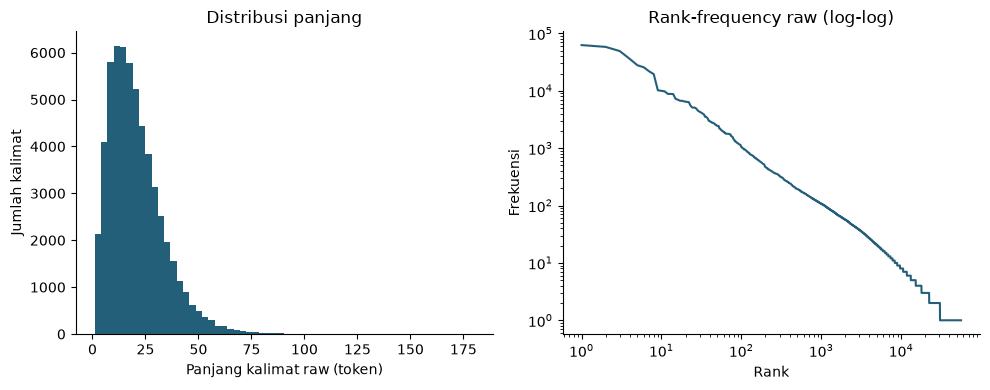

In [3]:
raw_counts = Counter(w for s in raw for w in s)
lengths = np.array([len(s) for s in raw])
raw_stats = {
    "sentences": len(raw),
    "tokens": int(lengths.sum()),
    "vocabulary": len(raw_counts),
    "mean_length": float(lengths.mean()),
}
display(pd.DataFrame([raw_stats]))
display(pd.DataFrame(raw_counts.most_common(20), columns=["token_raw", "count"]))
fig, axes = plt.subplots(1, 2)
axes[0].hist(lengths, bins=60, color="#245f7a")
axes[0].set(
    xlabel="Panjang kalimat raw (token)", ylabel="Jumlah kalimat", title="Distribusi panjang"
)
axes[1].loglog(
    np.arange(1, len(raw_counts) + 1), sorted(raw_counts.values(), reverse=True), color="#245f7a"
)
axes[1].set(xlabel="Rank", ylabel="Frekuensi", title="Rank-frequency raw (log-log)")
fig.tight_layout()
fig.savefig(OUT / "corpus.png", dpi=150)
plt.show()
results["raw"] = raw_stats

## 3 — Preprocessing
Lowercase, hanya alfabetik, hapus punctuation, buang kalimat kosong. Tokenisasi Brown sudah dilakukan corpus reader.

In [4]:
processed, dropped = preprocess(raw)
print("Original:", raw[0][:30])
print("Processed:", processed[0][:30])
print("Kalimat kosong dibuang:", dropped)
print("Kalimat/tokens processed:", len(processed), sum(map(len, processed)))
results["processed"] = {
    "sentences": len(processed),
    "tokens": sum(map(len, processed)),
    "empty_dropped": dropped,
}

Original: ['The', 'Fulton', 'County', 'Grand', 'Jury', 'said', 'Friday', 'an', 'investigation', 'of', "Atlanta's", 'recent', 'primary', 'election', 'produced', '``', 'no', 'evidence', "''", 'that', 'any', 'irregularities', 'took', 'place', '.']
Processed: ['the', 'fulton', 'county', 'grand', 'jury', 'said', 'friday', 'an', 'investigation', 'of', 'recent', 'primary', 'election', 'produced', 'no', 'evidence', 'that', 'any', 'irregularities', 'took', 'place']
Kalimat kosong dibuang: 574
Kalimat/tokens processed: 56766 981716


## 4 — Split data
Indeks kalimat disimpan sebagai bukti partisi. Semua fitting selanjutnya hanya memakai train.

In [5]:
train, test, train_ids, test_ids = split_sentences(processed, seed=42)
assert set(train_ids).isdisjoint(test_ids)
assert len(train_ids) + len(test_ids) == len(processed)
print("Train:", len(train), "Test:", len(test))
(OUT / "split.json").write_text(
    json.dumps({"train_ids": train_ids, "test_ids": test_ids}), encoding="utf-8"
)
results["split"] = {"train_sentences": len(train), "test_sentences": len(test)}

Train: 45412 Test: 11354


## 5 — Sentence boundary
Bigram satu BOS, trigram dua BOS, satu EOS. Boundary ditambahkan saat membentuk event; tidak masuk vocabulary leksikal.

In [6]:
for n in (2, 3):
    print(n, "train:", add_boundaries(train[0][:8], n))
    print(n, "test :", add_boundaries(test[0][:8], n))

2 train: ['<s>', 'she', 'called', 'trying', 'to', 'attain', 'a', 'half', 'humorous', '</s>']
2 test : ['<s>', 'at', 'one', 'time', 'to', 'most', 'americans', 'unless', 'they', '</s>']
3 train: ['<s>', '<s>', 'she', 'called', 'trying', 'to', 'attain', 'a', 'half', 'humorous', '</s>']
3 test : ['<s>', '<s>', 'at', 'one', 'time', 'to', 'most', 'americans', 'unless', 'they', '</s>']


## 6 — Unknown words
Ambang dua mengganti singleton train menjadi UNK agar target UNK dipelajari. OOV sebelum pemetaan dihitung terhadap vocabulary raw train dan vocabulary setelah ambang; setelah pemetaan nol secara representasi, bukan berarti semua kata asli dikenali.

In [7]:
vocabulary, train_word_counts = fit_vocabulary(train, min_count=2)
train_mapped = replace_unknown(train, vocabulary)
test_mapped = replace_unknown(test, vocabulary)
oov = {
    "raw_train_vocab_rate": oov_rate(test, set(train_word_counts)),
    "threshold_vocab_rate": oov_rate(test, vocabulary),
    "after_mapping_rate": oov_rate(test_mapped, vocabulary),
    "V_targets": len(vocabulary),
    "train_UNK_tokens": sum(w == "<UNK>" for s in train_mapped for w in s),
}
display(pd.DataFrame([oov]))
assert "<s>" not in vocabulary and "</s>" in vocabulary and "<UNK>" in vocabulary
results["oov"] = oov

,raw_train_vocab_rate,threshold_vocab_rate,after_mapping_rate,V_targets,train_UNK_tokens
0,0.01872,0.032408,0.0,22356,14533


## 7 — Generate N-grams
Fungsi generik `ngrams(tokens, n)`; model memakai `events()` dengan padding menurut orde.

In [8]:
example = add_boundaries(["the", "cat", "sleeps"], 2)
for n in (1, 2, 3):
    print(n, list(ngrams(example, n)))
print("Trigram dengan dua BOS:", list(events(["the", "cat", "sleeps"], 3)))

1 [('<s>',), ('the',), ('cat',), ('sleeps',), ('</s>',)]
2 [('<s>', 'the'), ('the', 'cat'), ('cat', 'sleeps'), ('sleeps', '</s>')]
3 [('<s>', 'the', 'cat'), ('the', 'cat', 'sleeps'), ('cat', 'sleeps', '</s>')]
Trigram dengan dua BOS: [('<s>', '<s>', 'the'), ('<s>', 'the', 'cat'), ('the', 'cat', 'sleeps'), ('cat', 'sleeps', '</s>')]


## 8 — Count N-grams
Counter target dan konteks dibentuk dari event prediksi yang sama. Akhir kalimat tidak dihubungkan ke kalimat berikutnya.

In [9]:
mle = {n: NGramLM(n, alpha=0, min_count=1).fit(train_mapped, vocabulary) for n in (1, 2, 3)}
for n in (2, 3):
    print("Top", n, "grams")
    display(pd.DataFrame(mle[n].counts.most_common(10), columns=["ngram", "count"]))
    print("Konteks unik:", len(mle[n].context_counts))

Top 2 grams


,ngram,count
0,"(of, the)",7723
1,"(<s>, the)",5685
2,"(in, the)",4880
3,"(to, the)",2809
4,"(<s>, he)",2402
5,"(on, the)",1975
6,"(and, the)",1850
7,"(<s>, it)",1709
8,"(the, <UNK>)",1703
9,"(<UNK>, </s>)",1690


Konteks unik: 22356
Top 3 grams


,ngram,count
0,"(<s>, <s>, the)",5685
1,"(<s>, <s>, he)",2402
2,"(<s>, <s>, it)",1709
3,"(<s>, <s>, in)",1470
4,"(<s>, <s>, i)",1450
5,"(<s>, <s>, but)",1214
6,"(<s>, <s>, a)",1015
7,"(<s>, <s>, and)",997
8,"(<s>, <s>, this)",940
9,"(<s>, <s>, they)",763


Konteks unik: 313594


## 9 — Maximum Likelihood Estimation
P(w|h)=C(h,w)/C(h). Konteks kosong-count menghasilkan 0. Contoh diambil dari count aktual, bukan angka ilustrasi.

In [10]:
rows = []
for n in (2, 3):
    for gram, count in mle[n].counts.most_common(3):
        rows.append(
            {
                "n": n,
                "ngram": gram,
                "count": count,
                "context_count": mle[n].context_counts[gram[:-1]],
                "P_MLE": mle[n].score(gram[-1], gram[:-1]),
            }
        )
display(pd.DataFrame(rows))
print("Konteks tak terlihat:", mle[2].score("the", ("</s>",)))

,n,ngram,count,context_count,P_MLE
0,2,"(of, the)",7723,29164,0.264813
1,2,"(<s>, the)",5685,45412,0.125187
2,2,"(in, the)",4880,17145,0.284631
3,3,"(<s>, <s>, the)",5685,45412,0.125187
4,3,"(<s>, <s>, he)",2402,45412,0.052894
5,3,"(<s>, <s>, it)",1709,45412,0.037633


Konteks tak terlihat: 0.0


## 10 — Next-word prediction
`predict_next(context, k=5)` mengurutkan probabilitas, tie-break alfabetik. Bigram memakai token terakhir; trigram memakai dua token terakhir.

In [11]:
predictions = []
for n in (2, 3):
    for context in ("the", "in the", "of the"):
        for word, probability in mle[n].predict_next(context):
            predictions.append(
                {"n": n, "context": context, "word": word, "probability": probability}
            )
display(pd.DataFrame(predictions))
results["predictions"] = predictions

,n,context,word,probability
0,2,the,<UNK>,0.030531
1,2,the,first,0.009591
2,2,the,same,0.009251
3,2,the,other,0.006113
4,2,the,most,0.006024
5,2,in the,<UNK>,0.030531
6,2,in the,first,0.009591
7,2,in the,same,0.009251
8,2,in the,other,0.006113
9,2,in the,most,0.006024


## 11 — Sentence probability
Produk probabilitas termasuk EOS. Satu event tak terlihat cukup membuat produk MLE nol.

In [12]:
seen_sentence = train_mapped[0]
unseen_sentence, unseen_gram = next(
    (s, g) for s in test_mapped for g in events(s, 2) if mle[2].counts[g] == 0
)
print("Kalimat train:", " ".join(seen_sentence))
print("P_MLE train:", sentence_probability(mle[2], seen_sentence))
print("Kalimat test:", " ".join(unseen_sentence))
print("Unseen bigram:", unseen_gram, "P kalimat:", sentence_probability(mle[2], unseen_sentence))
assert sentence_probability(mle[2], unseen_sentence) == 0

Kalimat train: she called trying to attain a half humorous resentment at his departure
P_MLE train: 9.775559170544628e-24
Kalimat test: at one time to most americans unless they were fortunate enough to live near a body of <UNK> water boats were considered the sole concern of fishermen rich people and the united states navy
Unseen bigram: ('americans', 'unless') P kalimat: 0.0


## 12 — Log probability
Natural log; `log(0)=-inf`. Kalimat panjang dibuat dengan mengulang token train; Laplace menjaga setiap event positif, sehingga nol produk merupakan underflow numerik.

In [13]:
laplace = {n: NGramLM(n, alpha=1, min_count=1).fit(train_mapped, vocabulary) for n in (1, 2, 3)}
long_sentence = seen_sentence * 100
product = sentence_probability(laplace[2], long_sentence)
log_value = sentence_log_probability(laplace[2], long_sentence)
print("Token panjang:", len(long_sentence), "produk:", product, "log P:", log_value)
print("log P MLE unseen:", sentence_log_probability(mle[2], unseen_sentence))
assert product == 0 and math.isfinite(log_value)
results["underflow"] = {
    "tokens": len(long_sentence),
    "product": product,
    "log_probability": log_value,
}

Token panjang: 1200 produk: 0.0 log P: -9826.710276870215
log P MLE unseen: -inf


## 13 — Zero-frequency problem
Persentase utama dihitung terhadap kemunculan bigram test (token-weighted). Persentase tipe unik dilaporkan terpisah.

In [14]:
test_bigrams = Counter(g for s in test_mapped for g in events(s, 2))
unseen_types = [g for g in test_bigrams if not mle[2].counts[g]]
unseen_rate = sum(test_bigrams[g] for g in unseen_types) / sum(test_bigrams.values())
print(
    "Bigram:",
    unseen_gram,
    "count train:",
    mle[2].counts[unseen_gram],
    "P:",
    mle[2].score(unseen_gram[-1], unseen_gram[:-1]),
)
print("Unseen occurrences:", unseen_rate, "unseen types:", len(unseen_types) / len(test_bigrams))
results["unseen_bigrams"] = {
    "occurrence_rate": unseen_rate,
    "type_rate": len(unseen_types) / len(test_bigrams),
    "example": unseen_gram,
}

Bigram: ('americans', 'unless') count train: 0 P: 0.0
Unseen occurrences: 0.26699215746578503 unseen types: 0.4966815708164923


## 14 — Laplace smoothing
P(w|h)=(C(h,w)+1)/(C(h)+V). V mencakup UNK dan EOS, mengecualikan BOS. Pemeriksaan **semua konteks teramati** menjumlahkan probabilitas kata terlihat dan massa seluruh V−T kata tak terlihat; konteks tak terlihat memiliki distribusi uniform. Pengelompokan ini identik dengan menjumlahkan seluruh vocabulary, dengan biaya lebih rendah.

In [15]:
normalization = {n: laplace[n].assert_laplace_normalized(1e-9) for n in laplace}
print("Konteks diperiksa:", normalization)
print("P Laplace unseen:", laplace[2].score(unseen_gram[-1], unseen_gram[:-1]))
assert laplace[2].score(unseen_gram[-1], unseen_gram[:-1]) > 0
results["normalization_contexts"] = normalization

Konteks diperiksa: {1: 1, 2: 22356, 3: 313594}
P Laplace unseen: 4.457718539651406e-05


## 15 — Evaluate with perplexity
PP=exp(−Σ log P/N); N mencakup satu EOS per kalimat. Bigram MLE bernilai inf bila test mengandung event nol. Grafik menampilkan nilai finite; inf diberi anotasi, tanpa nilai buatan.

,model,perplexity,predicted_tokens,log_likelihood
0,Bigram MLE,inf,208096,-inf
1,Unigram Laplace,8.458457e+02,208096,-1.402637e+06
2,Bigram Laplace,2.633393e+03,208096,-1.638970e+06
3,Trigram Laplace,1.097793e+04,208096,-1.936051e+06


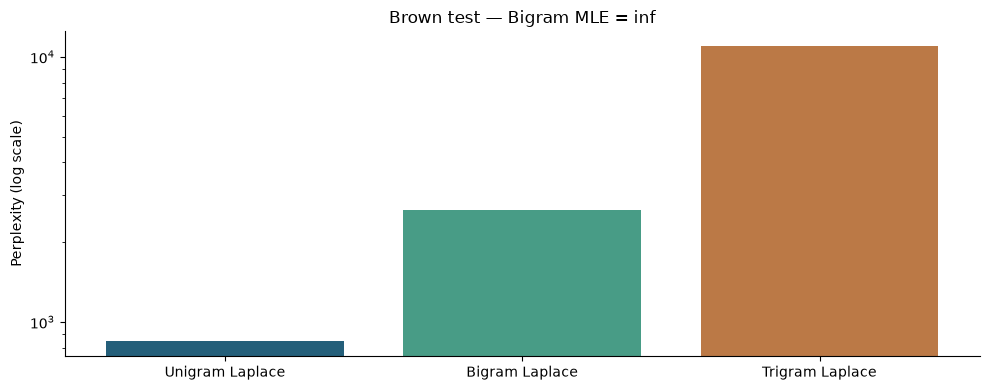

In [16]:
pp_rows = []
for label, model in [
    ("Bigram MLE", mle[2]),
    ("Unigram Laplace", laplace[1]),
    ("Bigram Laplace", laplace[2]),
    ("Trigram Laplace", laplace[3]),
]:
    metrics = perplexity(model, test_mapped)
    pp_rows.append({"model": label, **metrics})
pp_table = pd.DataFrame(pp_rows)
display(pp_table)
finite = pp_table[np.isfinite(pp_table.perplexity)]
fig, ax = plt.subplots()
ax.bar(finite.model, finite.perplexity, color=["#245f7a", "#489c86", "#bb7946"])
ax.set(yscale="log", ylabel="Perplexity (log scale)", title="Brown test — Bigram MLE = inf")
fig.tight_layout()
fig.savefig(OUT / "perplexity.png", dpi=150)
plt.show()
results["perplexity"] = [
    {k: (v if not isinstance(v, float) or math.isfinite(v) else str(v)) for k, v in r.items()}
    for r in pp_rows
]

Trigram Laplace dapat lebih buruk karena tiap konteks dua kata memiliki lebih sedikit pengamatan. Add-one membagi massa ke V target pada setiap konteks; konteks sparse mendekati uniform. Bandingkan angka di tabel, bukan menganggap orde lebih tinggi pasti lebih baik. PP ini hanya berlaku untuk tokenisasi dan vocabulary tersebut.

## 16 — Text generation
Sampling **MLE** untuk melihat koherensi lokal tanpa dilusi add-one. Mulai dengan n−1 BOS; berhenti EOS atau 40 kata. Lima seed tetap per model. UNK tetap terlihat agar keluaran tidak menyembunyikan batas model.

In [17]:
generated = {}
for n in (2, 3):
    generated[str(n)] = [generate(mle[n], seed=42 + i, max_length=40) for i in range(5)]
    print("Model", n)
    for i, s in enumerate(generated[str(n)], 1):
        print(i, " ".join(s))
results["generation"] = generated

Model 2
1 it was before the <UNK> level in both miss schwarzkopf and <UNK> <UNK> and left foot traveler and repair facilities for a joint committee of the stint of christendom
2 somewhere behind that we seldom moved a blind alley for an extraordinary effort to behave in that point charles <UNK> rapidly from squeezing a big one another car with dependable universe is not very troubled time
3 a sudden wave of men like a child continues to the united in
4 for him by the contemporary scene but that curious
5 although bob fogg made
Model 3
1 it was close to being social leaders and in the biography diffuse help to his italian <UNK>
2 somewhere birds were <UNK> by lighting
3 a change in the rear end was as if they were doing our best new england but roughly only a few moments before and the moral and spiritual awakening of an autistic child who is this
4 for if i had plenty status at the floor these can be changed without <UNK> rupture intermittently occurs along the roof of the house ahead 

Transisi MLE yang dihasilkan memiliki dukungan train; itu bukti koherensi statistik lokal saja. Tidak ada pengukuran koherensi semantik/global atau penilaian manusia di Fase 1. Pemotongan pada panjang maksimal tidak menjamin kalimat gramatikal.

## Gerbang verifikasi Fase 1
Test dijalankan dari notebook. Hasil, manifest corpus, indeks split, dan ringkasan disimpan setelah semua langkah selesai.

In [18]:
check = subprocess.run(
    [sys.executable, "-m", "pytest", "core/tests", "-q"],
    cwd=ROOT,
    capture_output=True,
    text=True,
    check=True,
)
print(check.stdout)
results["tests"] = check.stdout.strip()
(OUT / "metrics.json").write_text(
    json.dumps(results, ensure_ascii=False, indent=2, allow_nan=False), encoding="utf-8"
)
lines = [
    "# Ringkasan Fase 1",
    "",
    f"Brown: {len(raw):,} kalimat raw, {raw_stats['tokens']:,} token raw. Setelah filter: {len(processed):,} kalimat; {dropped} kosong dibuang.",
    f"Split seed 42: {len(train):,} train / {len(test):,} test. V={len(vocabulary):,}; UNK train={oov['train_UNK_tokens']:,}.",
    f"OOV test raw={oov['raw_train_vocab_rate']:.4%}; setelah threshold={oov['threshold_vocab_rate']:.4%}; setelah mapping={oov['after_mapping_rate']:.4%}.",
    "",
    "| Model | Perplexity | N target |",
    "|---|---:|---:|",
]
lines += [f"| {r['model']} | {r['perplexity']:.6g} | {r['predicted_tokens']:,} |" for r in pp_rows]
lines += [
    "",
    f"Unseen bigram test={unseen_rate:.4%} (kemunculan). Produk kalimat panjang={product}; log P={log_value:.6g} finite.",
    "",
    "Normalisasi semua konteks teramati lulus dengan toleransi 1e-9; konteks tak terlihat uniform. Test unit lulus (lihat metrics.json).",
    "",
    "Keterbatasan: satu seed, random split kalimat, kemungkinan kalimat identik/tema dokumen tumpang tindih. Tidak diuji: lintas corpus/bahasa, semantic coherence, penilaian manusia. Vocabulary/PP tidak bisa langsung dibandingkan dengan tokenisasi lain. Trigram add-one dapat memburuk karena sparse context dan pembagian massa ke seluruh V.",
]
(OUT / "SUMMARY.md").write_text("\n".join(lines) + "\n", encoding="utf-8")
print("Hasil tersimpan:", OUT)

...............                                                          [100%]
15 passed in 0.10s

Hasil tersimpan: D:\Dokumen\Semester 5\Pemrosesan Bahasa Alami\N gram\core\results
